In [ ]:
# import required libraries
from osgeo import gdal
from pathlib import Path
import geopandas as gpd
import subprocess

asc_folder = Path('data/rasters/scotland/ascs')
asc_folder.mkdir(parents=True, exist_ok=True)
dem_folder = Path('data/rasters/scotland/dems')
dem_folder.mkdir(parents=True, exist_ok=True)
warp_folder = Path('data/rasters/scotland/warped')
warp_folder.mkdir(parents=True, exist_ok=True)
gpkg_folder = Path('data/vectors/scotland/tiles/gpkgs')
gpkg_folder.mkdir(parents=True, exist_ok=True)
footprint_folder = Path('data/vectors/scotland/tiles/footprints')
footprint_folder.mkdir(parents=True, exist_ok=True)

In [ ]:
asc_dir = Path('/home/jamiemac/Documents/University/Loughborough/PhD/Project 1/Data/Scotland/rasters/dem_asc')
for asc in asc_dir.rglob('*.asc'):
    print(f'moving {asc.name} into {asc_folder}...')
    asc.move_into(asc_folder)
    print(f'moved {asc.name} successfully')
    print('')

In [ ]:
# ascs = [asc for asc in asc_folder.rglob('*.asc')]

In [ ]:
for asc in asc_folder.rglob('*.asc'):
    if (warp_folder / asc.name).exists():
        print(f'{asc.name} already processed. Skipping...')
        continue
    else:
        print(f'Reprojecting {asc.name}...')
        gdal.Warp(str(warp_folder / asc.name), asc, dstSRS='EPSG:27700')
        print(f'{asc.name} reprojected successfully.')

In [ ]:
for file in warp_folder.rglob('*.asc'):
    if Path(dem_folder / file.stem).with_suffix('.tif').is_file():
        print(f'{file.name} already processed. Skipping...')
        continue
    else:
        print(f'Converting {file.name}...')
        gdal.Translate((dem_folder / file.stem).with_suffix('.tif'), file, format='GTiff')
        print(f'{file.name} converted successfully.')


In [ ]:
for asc in asc_folder.rglob('*.asc'):
    if ((footprint_folder / asc.name)).with_suffix('.gpkg').exists():
        print(f'{asc.name} already processed. Skipping...')
        continue
    else:
        print(f'Finding footprint of {asc.name}...')
        gdal.Footprint(str((footprint_folder / asc.stem).with_suffix('.gpkg')), asc)
        print(f'Successfully found footprint of {asc.name}.')

In [57]:
for footprint in footprint_folder.iterdir():
    print(f'Processing {footprint.name}...')
    subprocess.run(['ogr2ogr', 
                    '-f', 
                    'GPKG', 
                    f'{gpkg_folder / footprint.name}', 
                    f'{footprint}'], check=True)
    print(f'Successfully processed {footprint.name}.')

Processing ND39SW.gpkg...
Successfully processed ND39SW.gpkg.
Processing NS96SW.gpkg...
Successfully processed NS96SW.gpkg.
Processing NG45SW.gpkg...
Successfully processed NG45SW.gpkg.
Processing NB23SE.gpkg...
Successfully processed NB23SE.gpkg.
Processing NO16SE.gpkg...
Successfully processed NO16SE.gpkg.
Processing NS71NE.gpkg...
Successfully processed NS71NE.gpkg.
Processing NT64SW.gpkg...
Successfully processed NT64SW.gpkg.
Processing NX99NE.gpkg...
Successfully processed NX99NE.gpkg.
Processing NY34NW.gpkg...
Successfully processed NY34NW.gpkg.
Processing NA81SE.gpkg...
Successfully processed NA81SE.gpkg.
Processing ND14SE.gpkg...
Successfully processed ND14SE.gpkg.
Processing NG79SW.gpkg...
Successfully processed NG79SW.gpkg.
Processing NY15NW.gpkg...
Successfully processed NY15NW.gpkg.
Processing NF85SW.gpkg...
Successfully processed NF85SW.gpkg.
Processing NM96NW.gpkg...
Successfully processed NM96NW.gpkg.
Processing NM32NE.gpkg...
Successfully processed NM32NE.gpkg.
Processi

<Axes: >

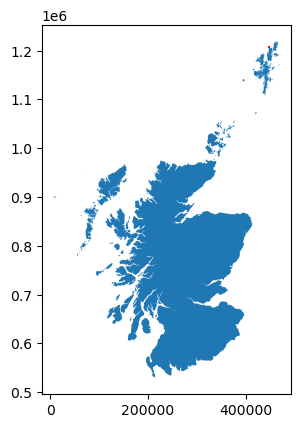

In [60]:
scotland = gpd.read_file('data/vectors/scotland/scotland.shp')
test = gpd.read_file('data/vectors/scotland/tiles/trial.gpkg').to_crs(epsg=27700)

ax = scotland.plot()
test.plot(ax=ax, fc='red')

In [ ]:
# locate tiles from the index which correspond to the periphery
if test[test.intersects(scotland.union_all())] == True:
    test.plot()


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:
vector = gpd.read_file(shp_folder / 'trial.shp')

vector.head()

In [ ]:
vector.plot()